In [1]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [2]:
# -----------------------------
# Example data
# -----------------------------
x = np.array([1, 2, 3, 4, 5, 6, 7, 8])
y = np.array([2.1, 4.0, 6.1, 7.9, 10.2, 12.1, 13.9, 16.2])
yerr = np.array([0.3, 0.3, 0.4, 0.3, 0.4, 0.3, 0.4, 0.3])


<ErrorbarContainer object of 3 artists>

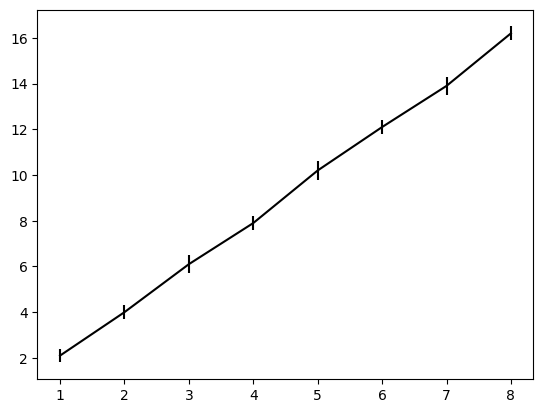

In [3]:
plt.errorbar(x, y, yerr=yerr, label="Data", color="black")

In [4]:

# -----------------------------
# Define models
# -----------------------------
def linear_model(x, a, b):
    return a * x + b

def quadratic_model(x, a, b, c):
    return a * x**2 + b * x + c

# -----------------------------
# Fit models
# -----------------------------
popt_linear, pcov_linear = curve_fit(
    linear_model, x, y, sigma=yerr, absolute_sigma=True
)

popt_quad, pcov_quad = curve_fit(
    quadratic_model, x, y, sigma=yerr, absolute_sigma=True
)


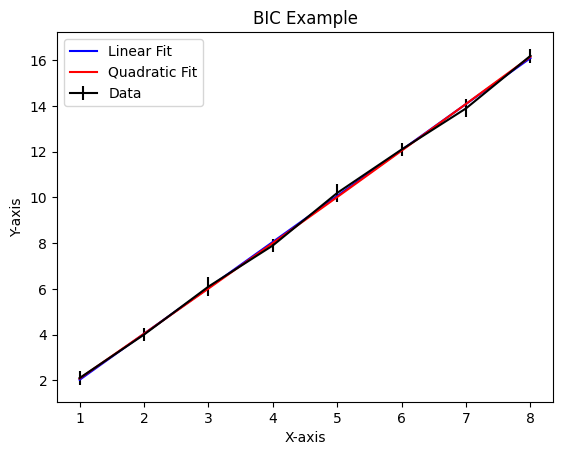

In [5]:
plt.errorbar(x, y, yerr=yerr, label="Data", color="black")
plt.plot(x, linear_model(x, *popt_linear), label="Linear Fit", color="blue")
plt.plot(x, quadratic_model(x, *popt_quad), label="Quadratic Fit", color="red")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("BIC Example")
plt.legend()
plt.show()

In [6]:

# -----------------------------
# Compute chi-square
# -----------------------------
residual_linear = y - linear_model(x, *popt_linear)
chi2_linear = np.sum((residual_linear / yerr)**2)

residual_quad = y - quadratic_model(x, *popt_quad)
chi2_quad = np.sum((residual_quad / yerr)**2)

# -----------------------------
# Compute BIC
# -----------------------------
n = len(y)

k_linear = len(popt_linear)      # a, b
k_quad = len(popt_quad)          # a, b, c

bic_linear = chi2_linear + k_linear * np.log(n)
bic_quad = chi2_quad + k_quad * np.log(n)

print("Linear fit parameters:")
print(popt_linear)

print("\nQuadratic fit parameters:")
print(popt_quad)

print("\nBIC results:")
print(f"Linear BIC    = {bic_linear:.3f}")
print(f"Quadratic BIC = {bic_quad:.3f}")

delta_bic = bic_quad - bic_linear
print(f"\nDelta BIC = BIC_quadratic - BIC_linear = {delta_bic:.3f}")

if bic_linear < bic_quad:
    print("Linear model is preferred.")
else:
    print("Quadratic model is preferred.")

Linear fit parameters:
[2.01106683 0.01296751]

Quadratic fit parameters:
[0.00887535 1.93157725 0.14032299]

BIC results:
Linear BIC    = 4.977
Quadratic BIC = 6.924

Delta BIC = BIC_quadratic - BIC_linear = 1.947
Linear model is preferred.


In [7]:
import numpy as np
from scipy.optimize import curve_fit

# ============================================================
# 1. Generate mock data
# ============================================================

np.random.seed(42)

x = np.linspace(0, 10, 40)

# True model: slightly curved relation
true_y = 1.5 + 2.0 * x - 0.12 * x**2

yerr = 0.8 * np.ones_like(x)
y = true_y + np.random.normal(0, yerr)

n = len(y)

# ============================================================
# 2. Define candidate models
# ============================================================

def linear_model(x, a, b):
    return a * x + b


def quadratic_model(x, a, b, c):
    return a * x**2 + b * x + c


def broken_line_model(x, m1, m2, xb, b):
    """
    Continuous broken-line model.

    For x < xb:
        y = m1 * x + b

    For x >= xb:
        y = m2 * x + constant

    The constant is chosen so that the two line segments connect
    continuously at x = xb.
    """
    y_left = m1 * x + b

    # Value of left branch at the break point
    yb = m1 * xb + b

    # Right branch connected continuously
    y_right = m2 * (x - xb) + yb

    return np.where(x < xb, y_left, y_right)

# ============================================================
# 3. Gaussian log-likelihood function
# ============================================================

def gaussian_log_likelihood(y, y_model, yerr):
    """
    Gaussian log-likelihood with known measurement uncertainties.

    ln L = -1/2 sum [ ((y - model)/sigma)^2 + ln(2 pi sigma^2) ]
    """
    return -0.5 * np.sum(
        ((y - y_model) / yerr)**2 + np.log(2 * np.pi * yerr**2)
    )


def compute_bic(log_likelihood_max, k, n):
    return -2 * log_likelihood_max + k * np.log(n)

# ============================================================
# 4. Fit each model
# ============================================================

# Linear model: k = 2 parameters
popt_linear, pcov_linear = curve_fit(
    linear_model,
    x,
    y,
    sigma=yerr,
    absolute_sigma=True
)

y_linear = linear_model(x, *popt_linear)
lnL_linear = gaussian_log_likelihood(y, y_linear, yerr)
bic_linear = compute_bic(lnL_linear, k=2, n=n)


# Quadratic model: k = 3 parameters
popt_quad, pcov_quad = curve_fit(
    quadratic_model,
    x,
    y,
    sigma=yerr,
    absolute_sigma=True
)

y_quad = quadratic_model(x, *popt_quad)
lnL_quad = gaussian_log_likelihood(y, y_quad, yerr)
bic_quad = compute_bic(lnL_quad, k=3, n=n)


# Broken-line model: k = 4 parameters
# Bounds prevent the break point from going far outside the data range.
p0_broken = [2.0, 0.5, 5.0, 1.0]  # m1, m2, xb, b

bounds_broken = (
    [-10, -10, x.min(), -50],
    [10, 10, x.max(), 50]
)

popt_broken, pcov_broken = curve_fit(
    broken_line_model,
    x,
    y,
    p0=p0_broken,
    bounds=bounds_broken,
    sigma=yerr,
    absolute_sigma=True,
    maxfev=10000
)

y_broken = broken_line_model(x, *popt_broken)
lnL_broken = gaussian_log_likelihood(y, y_broken, yerr)
bic_broken = compute_bic(lnL_broken, k=4, n=n)

# ============================================================
# 5. Compare results
# ============================================================

results = {
    "linear": {
        "k": 2,
        "params": popt_linear,
        "lnL": lnL_linear,
        "BIC": bic_linear,
    },
    "quadratic": {
        "k": 3,
        "params": popt_quad,
        "lnL": lnL_quad,
        "BIC": bic_quad,
    },
    "broken_line": {
        "k": 4,
        "params": popt_broken,
        "lnL": lnL_broken,
        "BIC": bic_broken,
    },
}

# Sort by BIC
sorted_results = sorted(results.items(), key=lambda item: item[1]["BIC"])

print("Model comparison using BIC")
print("==========================")

for name, result in sorted_results:
    print(f"\nModel: {name}")
    print(f"k        = {result['k']}")
    print(f"ln L max = {result['lnL']:.3f}")
    print(f"BIC      = {result['BIC']:.3f}")
    print(f"params   = {result['params']}")

best_model = sorted_results[0][0]

print("\nBest model by BIC:")
print(best_model)

print("\nDelta BIC relative to best model:")
bic_best = sorted_results[0][1]["BIC"]

for name, result in sorted_results:
    delta_bic = result["BIC"] - bic_best
    print(f"{name:12s}: Delta BIC = {delta_bic:.3f}")

Model comparison using BIC

Model: quadratic
k        = 3
ln L max = -43.833
BIC      = 98.732
params   = [-0.10242582  1.7605729   1.92890969]

Model: broken_line
k        = 4
ln L max = -44.778
BIC      = 104.311
params   = [1.17078972 0.083143   5.69133749 2.46333366]

Model: linear
k        = 2
ln L max = -63.925
BIC      = 135.227
params   = [0.7363147  3.59223496]

Best model by BIC:
quadratic

Delta BIC relative to best model:
quadratic   : Delta BIC = 0.000
broken_line : Delta BIC = 5.578
linear      : Delta BIC = 36.495
